In [1]:
import os
import pandas as pd

train_pos_path = "../data/aclImdb/train/pos"
train_neg_path = "../data/aclImdb/train/neg"
test_pos_path = "../data/aclImdb/test/pos"
test_neg_path = "../data/aclImdb/test/neg"

In [2]:
def load_dataset(folder):
    reviews = []

    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder, filename)

            with open(file_path, "r", encoding="utf-8") as file:
                reviews.append(file.read())

    return reviews

In [3]:
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

print(len(train_pos))
print(len(train_neg))
print(len(test_pos))
print(len(test_neg))

12500
12500
12500
12500


In [4]:
train_df = pd.DataFrame({
    "review": train_pos + train_neg,
    "label": [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    "review": test_pos + test_neg,
    "label": [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1
(25000, 2)
(25000, 2)


In [5]:
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

print("✅ Dataset shape checks passed.")

✅ Dataset shape checks passed.


In [6]:
# Basic dataset overview
print("TRAIN INFO")
print(train_df.info())

print("\nTRAIN DESCRIPTION")
print(train_df.describe(include="all"))

print("\nLABEL COUNTS")
print(train_df["label"].value_counts())

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB
None

TRAIN DESCRIPTION
                                                   review        label
count                                               25000  25000.00000
unique                                              24904          NaN
top     You do realize that you've been watching the E...          NaN
freq                                                    3          NaN
mean                                                  NaN      0.50000
std                                                   NaN      0.50001
min                                                   NaN      0.00000
25%                                                   NaN      0.00000
50%                                       

In [7]:
train_df["review_length"] = train_df["review"].apply(lambda x: len(x.split()))

print(train_df[["review_length", "label"]].describe())

       review_length        label
count   25000.000000  25000.00000
mean      233.787200      0.50000
std       173.733032      0.50001
min        10.000000      0.00000
25%       127.000000      0.00000
50%       174.000000      0.50000
75%       284.000000      1.00000
max      2470.000000      1.00000


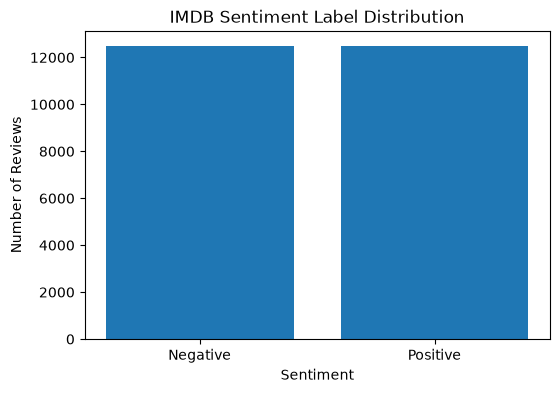

In [8]:
import matplotlib.pyplot as plt

# 1) Label distribution
label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], label_counts.values)
plt.title("IMDB Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

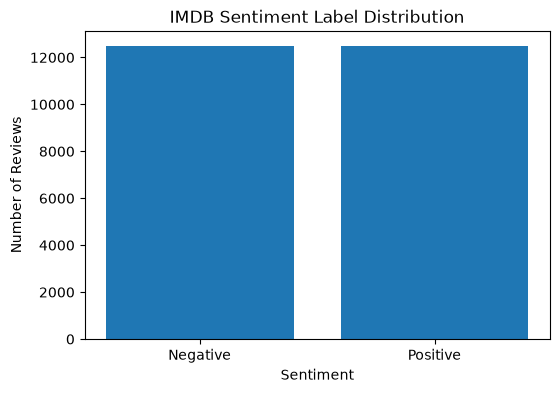

In [9]:
import matplotlib.pyplot as plt

# 1) Label distribution
label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative", "Positive"], label_counts.values)
plt.title("IMDB Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

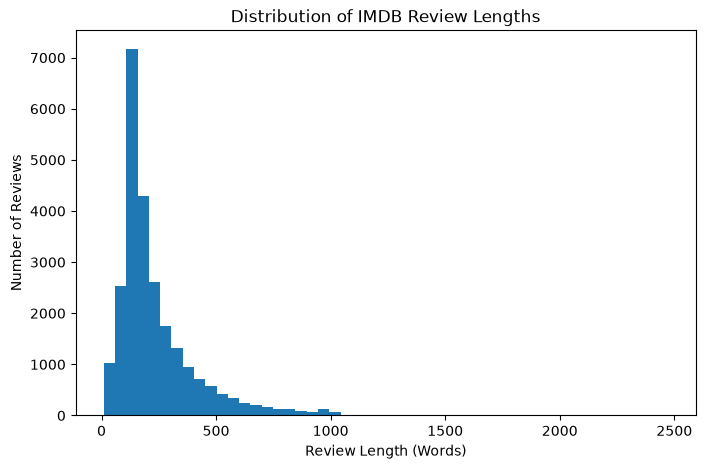

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["review_length"], bins=50)
plt.title("Distribution of IMDB Review Lengths")
plt.xlabel("Review Length (Words)")
plt.ylabel("Number of Reviews")
plt.show()

In [11]:
train_size = int(0.9 * len(train_df))

shuffled_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_df))

Training samples: 22500
Validation samples: 2500
Test samples: 25000


In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

d:\sentimentscope-transformer-ml-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
sample_texts = train_data["review"].sample(3, random_state=42).tolist()

tokenized_samples = tokenizer(
    sample_texts,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

In [14]:
sample_texts = train_data["review"].sample(
    3,
    random_state=42
).tolist()

tokenized_samples = tokenizer(
    sample_texts,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print(tokenized_samples["input_ids"].shape)
print(tokenized_samples["attention_mask"].shape)

torch.Size([3, 128])
torch.Size([3, 128])


In [15]:
import torch
from torch.utils.data import Dataset

MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB sentiment classification.
    """

    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        review = self.data.iloc[idx]["review"]
        label = self.data.iloc[idx]["label"]

        encoding = self.tokenizer(
            review,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)

        return input_ids, label

In [17]:
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 22500
Validation: 2500
Test: 25000


In [18]:
import numpy as np

assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

input_ids, label = train_dataset[0]

assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

print("✅ IMDBDataset checks passed.")
print("Input shape:", input_ids.shape)
print("Label:", label)

✅ IMDBDataset checks passed.
Input shape: torch.Size([128])
Label: 1


In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 704
Validation batches: 79
Test batches: 782


In [20]:
input_ids, labels = next(iter(train_loader))

print("Input batch shape:", input_ids.shape)
print("Label batch shape:", labels.shape)
print("Input dtype:", input_ids.dtype)
print("Label dtype:", labels.dtype)

Input batch shape: torch.Size([32, 128])
Label batch shape: torch.Size([32])
Input dtype: torch.int64
Label dtype: torch.int64


In [21]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "num_classes": 2,
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,
    "dropout_rate": 0.1,
    "use_bias": True
}

print(config)

{'vocabulary_size': 30522, 'num_classes': 2, 'd_embed': 128, 'context_size': 128, 'layers_num': 4, 'heads_num': 4, 'head_size': 32, 'dropout_rate': 0.1, 'use_bias': True}


In [22]:
import torch.nn as nn
import math

In [24]:
class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.Q_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.K_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.V_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(
            torch.ones(
                config["context_size"],
                config["context_size"]
            )
        )

        self.register_buffer(
            "casual_attention_mask",
            casual_attention_mask
        )

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape

        Q = self.Q_weights(input)
        K = self.K_weights(input)
        V = self.V_weights(input)

        attention_scores = Q @ K.transpose(1, 2)

        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[
                :tokens_num,
                :tokens_num
            ] == 0,
            float("-inf")
        )

        attention_scores = attention_scores / math.sqrt(K.shape[-1])

        attention_scores = torch.softmax(
            attention_scores,
            dim=-1
        )

        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

In [25]:
attention_head = AttentionHead(config).to(device)

dummy_input = torch.randn(
    BATCH_SIZE,
    config["context_size"],
    config["d_embed"]
).to(device)

attention_output = attention_head(dummy_input)

print(
    "AttentionHead output shape:",
    attention_output.shape
)

AttentionHead output shape: torch.Size([32, 128, 32])


In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        heads_list = [
            AttentionHead(config)
            for _ in range(config["heads_num"])
        ]

        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(
            config["heads_num"] * config["head_size"],
            config["d_embed"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [
            head(input)
            for head in self.heads
        ]

        x = torch.cat(heads_outputs, dim=-1)
        x = self.linear(x)
        x = self.dropout(x)

        return x

In [27]:
multi_head_attention = MultiHeadAttention(config).to(device)

dummy_input = torch.randn(
    BATCH_SIZE,
    config["context_size"],
    config["d_embed"]
).to(device)

mha_output = multi_head_attention(dummy_input)

print(
    "MultiHeadAttention output shape:",
    mha_output.shape
)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


In [28]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [30]:
feed_forward = FeedForward(config).to(device)

dummy_input = torch.randn(
    BATCH_SIZE,
    config["context_size"],
    config["d_embed"]
).to(device)

ff_output = feed_forward(dummy_input)

print(
    "FeedForward output shape:",
    ff_output.shape
)

FeedForward output shape: torch.Size([32, 128, 128])


In [31]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [32]:
block = Block(config).to(device)

dummy_input = torch.randn(
    BATCH_SIZE,
    config["context_size"],
    config["d_embed"]
).to(device)

block_output = block(dummy_input)

print(
    "Block output shape:",
    block_output.shape
)

Block output shape: torch.Size([32, 128, 128])


In [33]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"],
            config["d_embed"]
        )

        self.positional_embedding_layer = nn.Embedding(
            config["context_size"],
            config["d_embed"]
        )

        blocks = [
            Block(config)
            for _ in range(config["layers_num"])
        ]

        self.layers = nn.Sequential(*blocks)

        self.layer_norm = nn.LayerNorm(
            config["d_embed"]
        )

        # Classification head
        self.output_layer = nn.Linear(
            config["d_embed"],
            config["num_classes"],
            bias=False
        )

    def forward(self, token_ids):
        batch_size, tokens_num = token_ids.shape

        # Token embeddings
        x = self.token_embedding_layer(token_ids)

        # Positional embeddings
        positions = torch.arange(
            tokens_num,
            device=token_ids.device
        )

        pos_embed = self.positional_embedding_layer(
            positions
        )

        x = x + pos_embed.unsqueeze(0)

        # Transformer blocks
        x = self.layers(x)
        x = self.layer_norm(x)

        # Mean pooling across sequence dimension
        x = torch.mean(x, dim=1)

        # Binary classification logits
        logits = self.output_layer(x)

        return logits

In [34]:
demo_gpt = DemoGPT(config).to(device)

dummy_token_ids = torch.randint(
    0,
    config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
).to(device)

logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:")
print(logits[:2])

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
tensor([[ 0.0139, -0.0140],
        [-0.0412, -0.0732]], grad_fn=<SliceBackward0>)


In [35]:
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

print("✅ DemoGPT architecture checks passed.")

✅ DemoGPT architecture checks passed.


In [36]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate classification accuracy as a percentage.
    """
    model.eval()

    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)

            predictions = torch.argmax(logits, dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100

    return accuracy

In [37]:
model = DemoGPT(config).to(device)

validation_accuracy = calculate_accuracy(
    model,
    val_loader,
    device
)

print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 50.04%


In [38]:
import torch.optim as optim

EPOCHS = 3

model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

In [39]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(input_ids)

        # Calculate loss
        loss = criterion(logits, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        if (step + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{EPOCHS}], "
                f"Step [{step+1}/{len(train_loader)}], "
                f"Loss: {running_loss/100:.4f}"
            )
            running_loss = 0.0

    val_accuracy = calculate_accuracy(
        model,
        val_loader,
        device
    )

    print(
        f"Epoch {epoch+1} - "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/3], Step [100/704], Loss: 0.6883
Epoch [1/3], Step [200/704], Loss: 0.6710
Epoch [1/3], Step [300/704], Loss: 0.6446
Epoch [1/3], Step [400/704], Loss: 0.6271
Epoch [1/3], Step [500/704], Loss: 0.6021
Epoch [1/3], Step [600/704], Loss: 0.5830
Epoch [1/3], Step [700/704], Loss: 0.5599
Epoch 1 - Validation Accuracy: 73.24%
Epoch [2/3], Step [100/704], Loss: 0.5301
Epoch [2/3], Step [200/704], Loss: 0.5002
Epoch [2/3], Step [300/704], Loss: 0.5085
Epoch [2/3], Step [400/704], Loss: 0.5100
Epoch [2/3], Step [500/704], Loss: 0.4905
Epoch [2/3], Step [600/704], Loss: 0.4796
Epoch [2/3], Step [700/704], Loss: 0.4867
Epoch 2 - Validation Accuracy: 76.96%
Epoch [3/3], Step [100/704], Loss: 0.4587
Epoch [3/3], Step [200/704], Loss: 0.4324
Epoch [3/3], Step [300/704], Loss: 0.4331
Epoch [3/3], Step [400/704], Loss: 0.4341
Epoch [3/3], Step [500/704], Loss: 0.4166
Epoch [3/3], Step [600/704], Loss: 0.4257
Epoch [3/3], Step [700/704], Loss: 0.4134
Epoch 3 - Validation Accuracy: 79.16%


In [40]:
test_accuracy = calculate_accuracy(
    model,
    test_loader,
    device
)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 76.49%


In [41]:
import os

os.makedirs("../models", exist_ok=True)

checkpoint_path = "../models/sentimentscope_model.pt"

torch.save(
    model.state_dict(),
    checkpoint_path
)

print(f"✅ Model checkpoint saved to: {checkpoint_path}")

✅ Model checkpoint saved to: ../models/sentimentscope_model.pt


## Project Results

The transformer-based sentiment classification model achieved:

- Validation Accuracy: **79.16%**
- Test Accuracy: **76.49%**
- Training Epochs: **3**
- Batch Size: **32**
- Maximum Sequence Length: **128 tokens**
- Optimizer: **AdamW**
- Learning Rate: **3e-4**

The model successfully exceeded the project requirement of **75% test accuracy**.

## Key Takeaways

1. The custom Transformer architecture successfully learned sentiment patterns from IMDB movie reviews and generalized to unseen test data.
2. Validation accuracy improved consistently across training epochs, while training loss decreased, demonstrating effective model learning.
3. Subword tokenization with `bert-base-uncased` provided an efficient representation of movie-review text for Transformer-based classification.
4. Model performance can potentially be improved further through additional hyperparameter tuning, more training epochs, larger embedding dimensions, or deeper Transformer blocks.

In [42]:
import os

print("Checkpoint exists:", os.path.exists(checkpoint_path))
print(
    "Checkpoint size (MB):",
    round(os.path.getsize(checkpoint_path) / (1024 ** 2), 2)
)

Checkpoint exists: True
Checkpoint size (MB): 19.05
